# Calibration: Residential

This notebook explores the calibration of a risk analysis.

We'll build this out over time: each point below is labelled with a priority:
- (1): required
- (2): important
- (3): optional


### Proposed contents of the notebook:

- (1) Short explanation of why we calibrate
- (2) Link to the CLIMADA Calibration module and describe when to use it
- (1) Manual calibration via Entity file with one or two target values (e.g. AAL or RP losses, historic total event losses): set up a risk calculation, print out the results. Invite user to modify Entity file until it looks good
- (2) Manual calibration via impact function scaling with one or two target values: set up a risk calculation, print out the results. Invite the user to explore parameters until they find one that works
- (3) Automated calibration via impact function scaling with one or two target values: set up a risk calculation, print out the results. Loop through possible values to find an optimum
- (2) Manual calibration via Entity file with several target values (e.g. annnual crop yield, multiple admins): set up a risk calculation, choose a loss function, print out the results. Invite user to modify Entity file until it looks good
- (3) Visualise this too: scatter plot
- (3) Automated calibration via impact function scaling with several target values (e.g. annnual crop yield, multiple admins): set up a risk calculation, choose a loss function, loop through possible values to find an optimum, print out the results. 
- (3) Visualise this too: scatter plot
- (3) Provide different loss functions for the user to explore


## Overview

Calibration is often the trickiest part of any risk analysis. The goal of a CLIMADA calibration is to choose an impact function (or functions) that can best reproduce observations from previous events plus any other risk data you have.

We recommend always calibrating your risk model, even if you've had success with a particular impact function in the past. This is because
- Impact functions from the literature were almost always designed for different hazard models, different exposure data, and different contexts. They aren't transferrable to new contexts right out of the box.
- Impact functions change a lot with the resolution of your data. What is the impact of a 2 m flood depth? It is different if the model resolution is at the household scale (e.g. 50 m) compared to a neighbourhood scale (e.g. 2 km). If a high resolution model predicts 2 m flood depth at exactly the location of a house, we would expect to model serious damage. However if a 2 km x 2 km square is flooded at 2 m depth, we have to treat this as a summary statistic for that grid cell: there won't usually be a uniform 2 m flood everywhere. In this case we would usually expect a lower damage value, since it's unlikely every single house is affected by 2 m of flood depth (but of course it depends on what the flood model 'means' by a 2 m depth...). This is most clear in [wildfire modelling](https://gmd.copernicus.org/articles/14/7175/2021/gmd-14-7175-2021.html) – calibrated damage curves are very different at different resolutions: it's the difference between 'there is a fire at your house' (100% loss, usually), versus 'there is a fire in your town' (0-100% loss depending on the calibration...).
- Even at the same resolution, there are often biases in your hazard or exposure data. Maybe the population in your modelled region has been [historically under- or over-counted](https://davidoks.blog/p/a-lot-of-population-numbers-are-fake), maybe your hazard dataset overestimates the size of flooded regions compared to historical data, or doesn't represent a key process (most commonly: flash flooding). A calibration (partly) corrects these so that errors within the hazard and exposure data don't propagate through (as much) to the risk statistics. 
- Each study has its own context: there are always unmodelled, local conditions that can affect impacts, e.g. local construction materials and techniques, resilience and experience of previous events, existing defences, government effectiveness, socioeconomic conditions, etc.

In general calibrations need to be done for every combination of hazard type and exposure type that you are modelling. However, you will often find that one calibration can inform others – e.g. if you don't have many observations on damages to businesses in your study area, but you have information on damages to housing, and you know that your first-guess impact functions needed to be adjusted down, it's reasonable to assume you'll want to make a similar adjustment to the first-guess impact function for businesses (assuming the functions come from the same source).

Calibrations are usually done either by
    (1) **Manual calibration:** taking a first-guess impact function and manually adjusting it, repeating the risk calculation, comparing it to your observations, and repeating this until you are satisfied with the outputs
or
    (2) **Automated calibration:** specifying a family of impact functions, and using software to find the 'best' impact function within that family, according to some cost function that you specify.
or
    (3) some combination of the both! Where you get a sense of the kind of impact functions that work in your study, and then refine.

The approach that works best for you will depend on the number of observations that you're fitting to, other constraints in what you consider to be an acceptable solution, the complexity of code that you're prepared to write, and the time you have available. With approach (2) there is no limit to the complexity of algorithms you can design to search parameter spaces and optimise within constraints. See for example the new [Calibration module](https://climada-python.readthedocs.io/en/v6.1.0/user-guide/climada_util_calibrate.html) within CLIMADA, designed (for now) for calibrations where you are modelling a set of events where each has an observed loss.


**Tips:**
- Before you start calibrating get an understanding of your data. Ask yourself some of the following:
    - What is the rough shape of the impact function you are creating? Do impacts start slowly or quickly? What would the maximum impact be? What shape does the curve take?
    - In your model, what range of hazard value intensities affect the assets that you're modelling? Your function should be defined across this range. (Check in the data – you are creating an impact function for the hazard that you have, not the hazard that you imagine.)
    - Are your losses driven by small impacts at lots of locations, or large impacts at a few locations? This will tell you which part of the curve to focus on.
    - (If you have multiple events or return periods in your hazard data:) Are historical losses more from large, rare events, or from more frequent events that occur e.g. every few years? This will tell you which events to focus on getting right.
    - What forms have been used elsewhere in the literature and are they appropriate?
- The impact of zero hazard should usually be zero. If this is not the case (e.g. with temperature or drought data), we recommend transforming or masking the hazard (e.g. setting all values to zero below some threshold at which impacts start) so that 0 hazard has zero impact. This greatly speeds up the calculations and avoids unexpected bugs.
- CLIMADA behaves better when impact functions increase with hazard – if you're working with something where this isn't the case (e.g. drought indices, extreme cold), it's recommended to invert the hazard so that impacts increase as the hazard increases.
- Make sure that you are calculating something represented by your summary statistics, or something that is close. For example:
    - Make sure the area you are modelling matches the area that your observations apply to (Ica is both a city and a Departement in Peru!).
    - Make sure the hazard data represents the processes you care about (a river flood model will struggle to reproduce flash flood losses, a drought model will struggle to reproduce heatwave losses).
- In some calibrations you will want to go beyond just the impact function, and will decide to adjust other parts of the risk calculation. For example:
    - You may want to apply bias corrections to the hazard data (e.g. corrections to flood data based on gauge histories, corrections to rainfall intensities based on an observational dataset)
    - If you are consistently getting high or low losses, check if your exposure values could be biased low (e.g. sometimes building replacement costs are more than the building value (but less than the value of the building + land, take note of what your value date represents!)). There may be a reason to scale the values of Exposures
    - You may have knowledge about something the model represents poorly: e.g. an area that is well-defended against floods and which you may choose to mask from the hazard, or a new neighborhood or piece of infrastructure not in the Exposure data


## Automated calibration to multiple observations

In this notebook we explore simple optimization routines designed to help choose appropriate impact functions for our modelling.

This notebook is for modelling risk for housing.

In this calculation, we will
- Read in and visualize the individual components of risk
- Write reusable methods to run the risk calculation and to compare the results to the observations
- Define a cost function to quantify how well the model is able to reproduce observations
- Write an optimization routine that tries to minimise this cost function over a family of impact functions. We do this for
  - Affected housing (calibrating a step function)
  - Destroyed housing (calibrating a step function)
  - Recovery costs (Adjusting an existing loss curve)


In [1]:
from pathlib import Path

# Set up paths to data
ENTITY_DIR = "../data/entity_files_uncalibrated/"
ENTITY_FILE = "ICA_PERU_Entity_Floods_Residential.xlsx"
entity_filepath = Path(ENTITY_DIR) / ENTITY_FILE

CALIBRATED_ENTITY_DIR = "../data/entity_files_calibrated/"
CALIBRATED_ENTITY_FILE = "ICA_PERU_Entity_Floods_Residential_calibrated.xlsx"
calibrated_entity_filepath = Path(CALIBRATED_ENTITY_DIR) / CALIBRATED_ENTITY_FILE

HAZARD_DIR = "../data/hazard/"
HAZARD_FILES = ["tr10_h_max_61200_4326.tif", "tr25_h_max_61200_4326.tif", "tr50_h_max_61200_4326.tif", "tr100_h_max_61200_4326.tif", "tr200_h_max_61200_4326.tif", "tr500_h_max_72000_4326.tif"]
haz_filepaths = [Path(HAZARD_DIR) / filename for filename in HAZARD_FILES]

OBSERVATIONS_DIR = "../data/observations/"
OBSERVATIONS_FILE = "observations_by_rp_residential.csv"
observations_filepath = Path(OBSERVATIONS_DIR) / OBSERVATIONS_FILE


## Load the components of risk

During the calibration we will be running risk calculations and plotting outputs repeatedly. To do this, we wrap the functionality of the central loop in reusable methods.

### Load the Entity file

In [2]:
import copy
from climada.entity import Entity

impf_column = "impf_FL"   # Impact function column in the assets table
impf_id_loss = 101        # ID of the impact function for economic loss that we're calibrating
impf_id_affected = 102    # ID of the impact function for affected homes that we're calibrating
impf_id_destroyed = 103   # ID of the impact function for destroyed homes that we're calibrating

# Read the Entity file
def read_entity(path, value_column):
    entity = Entity.from_excel(path)
    entity.ref_year = 2025
    entity.value_unit = "USD" if value_column == 'value' else "number of houses"
    entity.description = "Reconstruction costs" if value_column == 'value' else "Number of houses"

    # In the calibration, we calibrate against _number of buildings_ that are affected or destroyed
    # In the Entity file the 'value' column contains building value information in USD, and the e.g. 'housing_count' 
    # column contains the number of buildings. So we rename the columns so that the 'value' column contains the 
    # information we want.
    if value_column == 'value':
        return entity
    new_gdf = entity.exposures.gdf.copy()
    new_gdf["value"] = new_gdf[value_column]
    entity.exposures.set_gdf(new_gdf)
    return entity

# Read the Entity file for USD value
entity_usd = read_entity(entity_filepath, value_column='value')
entity_usd.exposures.ref_year = 2025
entity_usd.exposures.value_unit = "USD"
entity_usd.exposures.description = "Housing value"

# Read the Entity file for housing count
entity_count = read_entity(entity_filepath, value_column='housing_count')
entity_count.exposures.ref_year = 2025
entity_count.exposures.value_unit = "number of houses"
entity_count.exposures.description = "Number of houses"

#### Plot exposures

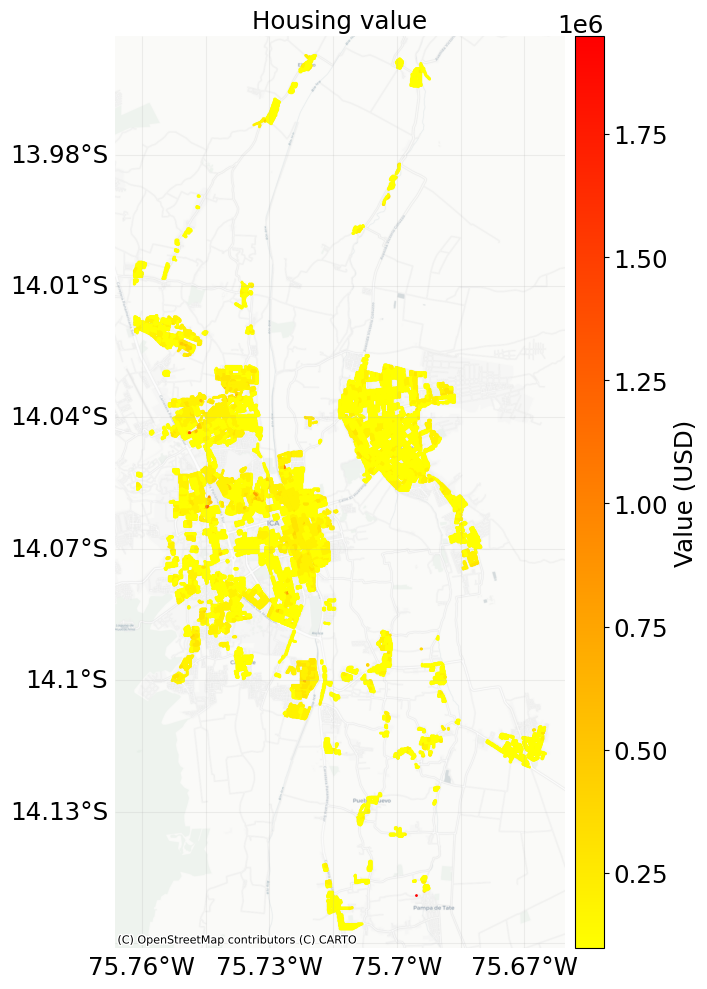

In [3]:
# Plot the exposures
_ = entity_usd.exposures.plot_basemap(
        ignore_zero=True,       # Whether to plot points with zero value
        buffer=500,              # Add a buffer around the points to show a larger map region (measured in meters)
        s=1,                     # The size of point markers on the plot
        zoom=14,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)         # Dimensions of the output figure
    )


#### Plot impact functions

There are a few ways to approach a calibration like this, depending on the statistics you want to produce and the purposes of the calibration.

Our approach is going to look at three flood damage curves, each describing a different risk metric:
- A depth-damage curve that estimates the % loss at a point of exposure. We want to calibrate this to give realistic losses, but we don't have loss numbers for losses in the study area, so this has to be calibrated through other curves.
- An 'affected' step-function. This gives the threshold at which a household is considered to be affected by the flood
- A 'destroyed' step-function. This gives the threshold at which a household is considered to be destroyed, and must be rebuilt.

Note: a simpler calibration might just calibrate the second and third of the above impact functions: they are independent and can be used for recovery cost estimations by themselves. However, given a few assumptions, we can attempt all three.

We have first-guess versions of these three impact functions in the Entity file:

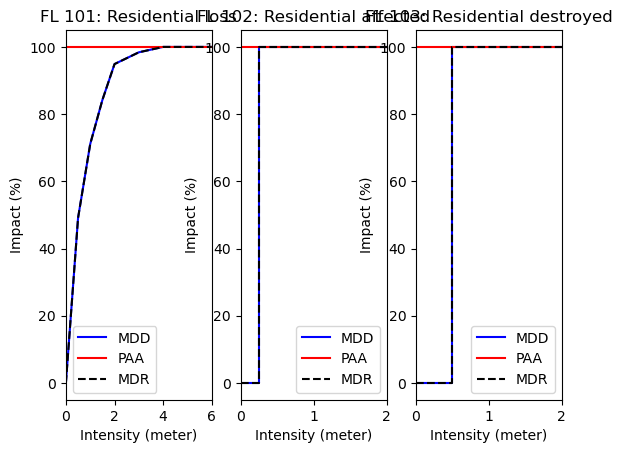

In [4]:
# Plot the impact functions
_ = entity_usd.impact_funcs.plot()

### Load Hazard data

As show in the earlier notebook, we read the hazard information from multiple .tif files, each containing a flood footprint with a different return period.

We provide additional metadata to CLIMADA as we do this, including event frequency data, calculated so that return period frequencies are recreated when their cumulative probability is calculated. We also remove locations where there is no flood hazard.

In [5]:
import numpy as np
from climada.hazard import Hazard

# Since we're reading hazard data from .tif files, we need to provide some additional metadata, including a frequency for each event
HAZARD_RETURN_PERIODS = [10, 25, 50, 100, 200, 500]

def event_frequency_from_return_periods(return_periods):
    rp_rev = copy.deepcopy(return_periods)[::-1]  # Reverse the list so that it's in order of increasing frequency (decreasing return period)
    exceedance_frequency = np.array([1/rp for rp in rp_rev])
    event_frequency = np.diff(np.concatenate([[0], exceedance_frequency]))
    event_frequency = event_frequency[::-1]  # Reverse the frequencies so that they match the order of the events in the hazard file again
    return event_frequency

event_frequency = event_frequency_from_return_periods(HAZARD_RETURN_PERIODS)


# Read in the hazard data
def read_hazard(haz_filepaths):
    haz = Hazard.from_raster(
        files_intensity = haz_filepaths,
        attrs={
            'unit': 'm',
            'event_name': [f'Return period {rp}' for rp in HAZARD_RETURN_PERIODS],     # We can optionally name the events
            'frequency': event_frequency                                         # For probabilistic analyses we have to deifine the frequency of each event
        },
        haz_type='FL',
        window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
        geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
    )

    # Drop hazard centroids with low or zero hazard
    intensity_threshold = 0.05       # [5 cm and less we'll ignore. Maybe this should be 0. Maybe this should be more – you can experiment]
    ix = haz.intensity.max(axis=0) < intensity_threshold    # Use the hazard intensity matrix to identify centroids 
    assert ix.sum() > 0     # Ensure this hasn't removed all cpoints
    ix = ix.todense().A1  # Convert from sparse matrix to 1D array of booleans
    # Remove any grid cells with zero intensity across all events
    haz.centroids.gdf["region_id"] = ix.astype(int)   # (bit hacky) set the hazard's centroid region IDs to 0 (centroid affected) or 1 (centroid never affected)
    haz = haz.select(reg_id=0)  # Subset the Hazard to only include grid cells with non-zero intensity across all events
    # Add any extra code here to process your Hazard file
    return haz


haz = read_hazard(haz_filepaths)

2026-06-04 08:53:42,184 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-06-04 08:53:48,414 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-06-04 08:53:48,608 - climada.util.coordinates - INFO - Reading ../data/hazard/tr25_h_max_61200_4326.tif
2026-06-04 08:53:48,793 - climada.util.coordinates - INFO - Reading ../data/hazard/tr50_h_max_61200_4326.tif
2026-06-04 08:53:48,985 - climada.util.coordinates - INFO - Reading ../data/hazard/tr100_h_max_61200_4326.tif
2026-06-04 08:53:49,178 - climada.util.coordinates - INFO - Reading ../data/hazard/tr200_h_max_61200_4326.tif
2026-06-04 08:53:49,369 - climada.util.coordinates - INFO - Reading ../data/hazard/tr500_h_max_72000_4326.tif


/usr/local/Caskroom/miniforge/base/envs/climada_env/lib/python3.11/site-packages/scipy/sparse/_base.py:463: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  return self.tocsr().__lt__(other)


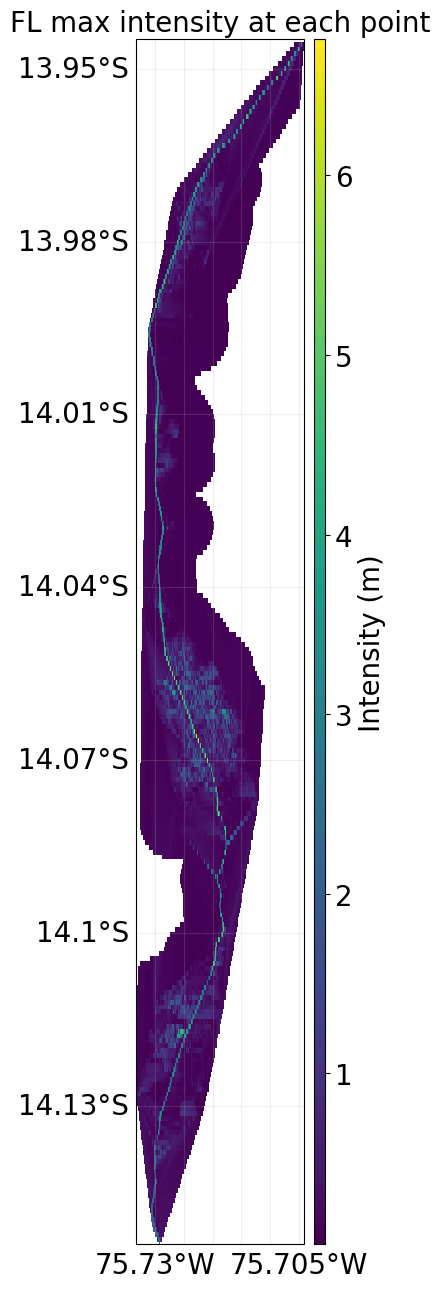

In [6]:
# Plot the maximum intensity across all events
_ = haz.plot_intensity(event=0)

In [7]:
# We need to choose an appropriate distance threshold for CLIMADA to use to match exposures to hazard centroids
# We want something large enough that points within a block of housing get matched to a flood on the street outside
# but small enough that points that are distant from the flood don't get matched to it.

# In the Uncalibrated Risk notebook we found a suitable distance matching threshold for this dataset.
MATCH_THRESHOLD = 0.0002
entity_usd.exposures.assign_centroids(hazard=haz, threshold=MATCH_THRESHOLD, overwrite=True)
entity_count.exposures.assign_centroids(hazard=haz, threshold=MATCH_THRESHOLD, overwrite=True)

2026-06-04 08:53:59,975 - climada.entity.exposures.base - INFO - Matching 107016 exposures with 282071 centroids.
2026-06-04 08:54:00,324 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0002 degree
2026-06-04 08:54:00,941 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000200 degree for 99557 coordinates.
2026-06-04 08:54:00,950 - climada.entity.exposures.base - INFO - Matching 107016 exposures with 282071 centroids.
2026-06-04 08:54:01,292 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0002 degree
2026-06-04 08:54:01,916 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000200 degree for 99557 coordinates.


### Load observations

As processed in previous notebooks.

In [8]:
import pandas as pd

obs = pd.read_csv(observations_filepath).set_index("rp")
display(obs.style.format({
    "homes_affected_present": "{:,.1f}",
    "homes_destroyed_present": "{:,.1f}",
    "affected_or_destroyed_present": "{:,.1f}",
    "recovery_cost_usd": "${:,.0f}"
}))

,homes_affected_present,homes_destroyed_present,affected_or_destroyed_present,recovery_cost_usd
rp,,,,
92.000000,"4,897.4",149.7,"5,047.1","$21,790,936"
9.000000,82.1,0.0,82.1,"$349,611"
6.000000,15.2,1.3,16.4,"$72,494"


## Write methods for reusable risk calculations

We calibrate the impact functions by running risk calculations, adjusting the impact functions, and attempting to reproduce the observations that we have.

In [9]:
import matplotlib.pyplot as plt
import contextily as ctx
from climada.entity import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc, ImpactFreqCurve, Impact

# ----------------------------------------
# Methods for risk calculations
# ----------------------------------------

# Run a risk calculation and extract impact statistics at our chosen return periods
def risk_calc(entity, hazard, return_periods):
    entity.exposures.assign_centroids(hazard=hazard, threshold=MATCH_THRESHOLD, overwrite=False)
    imp = ImpactCalc(entity.exposures, entity.impact_funcs, hazard).impact(save_mat=False, assign_centroids=False)
    rp_impacts = imp.calc_freq_curve(return_per=return_periods).impact
    return imp, pd.Series(rp_impacts, index=return_periods)


# Define a cost function that says how 'close' our modelled outputs are to the observations
# The automated calibration will use this to decide how well the model performs and will try to minimize its value
# Common options are
# - the (weighted) mean squared error between modelled and observed statistics
#     - with weights according to importance of different observations
#     - this prioritises getting large impacts correct
# - the (weighted) mean squared log error between modelled and observed statistics
#     - this priorises getting the order of magnitude of impacts correct
def cost_function(modelled, observed):
    assert np.all(modelled.index == observed.index), "Modelled and observed statistics must have the same index"
    cost = np.sqrt(((modelled - observed) ** 2).mean())
    return cost

# Swap a new impact function into an Entity file
# and assign its ID for all exposure points
def replace_impact_function(entity, new_impf):
    entity_new = copy.deepcopy(entity)    
    entity_new.impact_funcs = ImpactFuncSet([new_impf])
    gdf_new = copy.deepcopy(entity_new.exposures.gdf)
    gdf_new['impf_FL'] = new_impf.id
    entity_new.exposures.set_gdf(gdf_new)
    return entity_new

# ----------------------------------------
# Methods for visualzation
# ----------------------------------------

def plot_observations_vs_modelled(observed: pd.Series, modelled: pd.Series, title: str=None):
    fig, axis = plt.subplots(figsize=(6, 3))
    sc = axis.scatter(observed, modelled, c=observed.index, cmap="copper", label="Observations")
    cbar = plt.colorbar(sc, ax=axis)
    cbar.set_label("Observation return period")
    axis.plot([observed.min(), observed.max()], [observed.min(), observed.max()], "k--", label="1:1 line")   # Add a 1:1 line for reference
    axis.set_xlabel("Observed")
    axis.set_ylabel("Modelled")
    if title is not None:
        axis.set_title(title)
    axis.legend(loc="upper left")
    plt.show()
    plt.close(axis.figure)


# Plot the exceedance curve
def plot_exceedance(imp: Impact, observed: pd.Series, title: str=None):
    exceedance_curve = imp.calc_freq_curve()
    fig, axis = plt.subplots(figsize=(6, 3))
    axis = exceedance_curve.plot(axis=axis, color="blue", label="Modelled exceedance curve")
    sc = axis.scatter(observed.index, observed.values, c=observed.index, cmap="copper", label="Observations")
    cbar = plt.colorbar(sc, ax=axis)
    cbar.set_label("Observation return period")

    axis.set_xlim(0, 200)  # Zoom in on lower return periods
    if title is not None:
        axis.set_title(title)
    axis.legend(loc="upper left")
    plt.show()
    plt.close(axis.figure)


# Plot bar chart of losses for individual events (by category or region if desired)
# Specify 'split_exposure_by' to break down the losses by category or region. This should be a column in the exposures gdf, e.g. "category_id" or "region_id"
def plot_event_losses(imp: Impact, split_exposure_by: str=None, title: str=None):
    fig, axis = plt.subplots(figsize=(6, 3))
    if split_exposure_by is None:
        axis.bar(imp.event_name, imp.at_event)
    else:
        imp_at_reg = imp.impact_at_reg(agg_regions=entity.exposures.gdf[split_exposure_by])
        bottom = np.zeros(len(imp.at_event))
        for column in imp_at_reg.columns:
            p = axis.bar(imp.event_name, imp_at_reg[column], label=column, bottom=bottom)
            bottom += imp_at_reg[column]
        axis.legend(loc="upper left")
    axis.set_xlabel("Event Name")
    axis.set_ylabel(f"Impact ({imp.unit})")
    axis.tick_params(axis="x", rotation=45)
    if title is not None:
        axis.set_title(title)
    plt.show()
    plt.close(axis.figure)


# Map expected annual impacts
def plot_map(imp: Impact, title: str=None):
    axis = imp.plot_basemap_eai_exposure(
        ignore_zero=True,  # Only show at-risk assets
        buffer=500,
        s=2,
        zoom=14,
        url=ctx.providers.CartoDB.Positron,
        cmap="autumn_r",
        figsize=(6, 10)
    )
    if title is not None:
        axis.set_title(title)
    plt.show()
    plt.close(axis.figure)


## Affected housing calibration: step function

We can start with calibrating functions for affected housing. 'Affected' is considered to be a binary here – all of the houses at an exposure point are affected or they aren't.

This is modelled with a step function. Step functions are the simplest to calibrate: they start at zero impact and jump to 100% – the only thing that has to be determined is the threshold at which this happens.

CLIMADA has a method for building new step impact functions – `ImpactFunc.from_step_impf` and we will use this to find the one that best explains the data that we have.

### First-guess analysis

Our Entity file has a first-guess impact function for affected housing. This is what we'll be improving on:

2026-06-04 08:54:02,143 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-04 08:54:02,159 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.


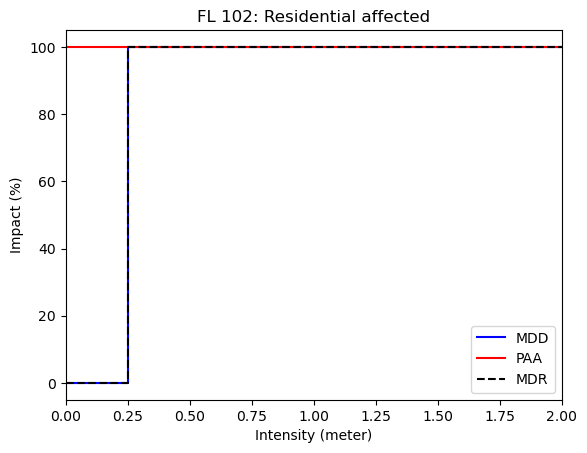

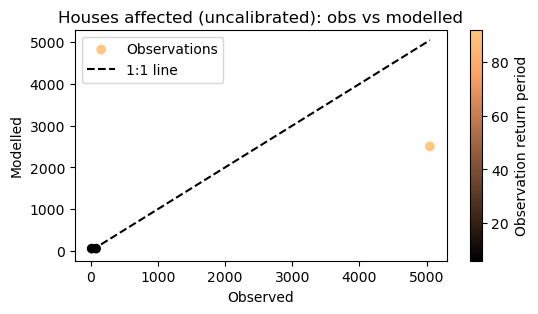

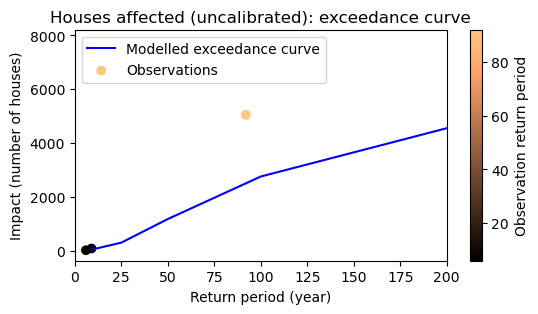

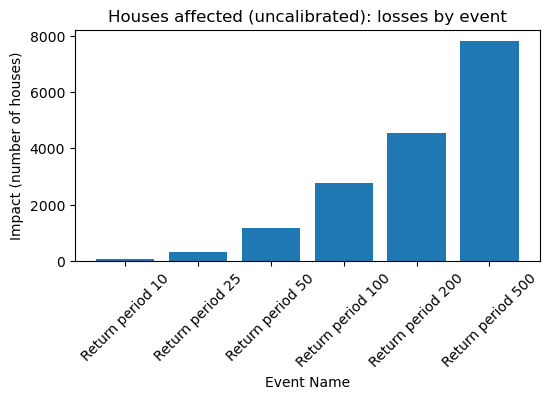

In [10]:
# Modify our Entity to use the default 'affected' impact function
default_impf_affected = entity_count.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_affected)
entity_affected = replace_impact_function(entity_count, default_impf_affected)

# Calculate risk
imp_affected, modelled_affected = risk_calc(entity_affected, haz, return_periods=obs.index)
cost = cost_function(modelled_affected, obs["affected_or_destroyed_present"])

# Create plots
entity_affected.impact_funcs.plot()
title = f"Houses affected (uncalibrated): obs vs modelled"
plot_observations_vs_modelled(obs["affected_or_destroyed_present"], modelled_affected, title)
title = f"Houses affected (uncalibrated): exceedance curve"
plot_exceedance(imp_affected, obs["affected_or_destroyed_present"], title)
title = f"Houses affected (uncalibrated): losses by event"
plot_event_losses(imp_affected, title=title)


#### Discussion: first-guess housing affected analysis

The intial plots show us a few things that can guide the calibration:
- We're improving on a first-guess step function where a house is affected if it has 0.25 m of water or more
- This significantly underestimates the impacts from the largest event that we have

This means that we want to reduce the threshold of the step function to increase the number of affected houses.


### Affected housing: parameter search

The next blocks of code define a simple parameter search to choose this value.

In [11]:
import logging

# This will be a simple grid search, where we loop through all combinations of parameters in a defined parameter space, run the risk calculation for each combination, and calculate the cost function for each combination. 
# We then identify the parameter combination that gives the lowest cost function value.

# First: define the parameter space that we'll be exploring
# For a step function this is a single parameter:
parameter_space = {
    "step": np.arange(0.0, 0.55, 0.05)
}

# Define a method to create a step impact function
def step_function(step, fun_id=None, name=None):
    return ImpactFunc.from_step_impf(
        intensity=(0, step, 3),   # The intensity values at which the impact function changes.
        mdd=(0, 1),                # The mean damage degree values below and above the step.
        paa=(1, 1),                # The percentage of assets affected below and above the step.
        haz_type='FL',
        impf_id=fun_id,
        intensity_unit="meter",
        name=name
    )


# Then, we loop through the parameter space, run the risk calculation, and calculate the cost function for each value.
# We store the results in a list.
def search_for_step_impf(
        entity: Entity,
        impf_id: int,
        step_values: np.ndarray,
        obs: pd.Series):
    # Suppress logging from a couple of climada modules which can be very verbose when running many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for step in step_values:
        print(f"Running risk calculation for step={step:.2f} ...")
            
        # Create a new impact function based on the original
        impf_old = entity.impact_funcs.get_func(haz_type='FL', fun_id=impf_id)
        impf_new = step_function(step, fun_id=impf_id, name=impf_old.name)

        # Update the entity object with the new impact function
        entity_new = replace_impact_function(entity, impf_new)

        # Rerun the risk calculation and calculate the cost function as before
        _, modelled_stats = risk_calc(entity_new, haz, return_periods=obs.index)
        cost = cost_function(modelled_stats, obs)

        # Store the results
        results.append({
            "step": step,
            "cost": cost
        })

    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)
    return pd.DataFrame(results)


results_affected_df = search_for_step_impf(
    entity=entity_affected,
    impf_id=impf_id_affected,
    step_values=parameter_space["step"],
    obs=obs["affected_or_destroyed_present"]
)
display(results_affected_df)

Running risk calculation for step=0.00 ...
2026-06-04 08:54:02,708 - climada.hazard.base - WARNING - Impact function id=102 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
Running risk calculation for step=0.05 ...
Running risk calculation for step=0.10 ...
Running risk calculation for step=0.15 ...
Running risk calculation for step=0.20 ...
Running risk calculation for step=0.25 ...
Running risk calculation for step=0.30 ...
Running risk calculation for step=0.35 ...
Running risk calculation for step=0.40 ...
Running risk calculation for step=0.45 ...
Running risk calculation for step=0.50 ...


,step,cost
0,0.00,1043.986796
1,0.05,1136.811477
2,0.10,1226.440995
3,0.15,1311.581459
4,0.20,1395.381213
5,0.25,1468.574032
6,0.30,1539.226029
7,0.35,1608.680337
8,0.40,1673.619199
9,0.45,1747.718456


From this search we can identify the 'best' impact function and visualize the results:

In [12]:
# Get the index of the minimum value of 'cost'
def get_best_result(results_df):
    ix_best = results_df['cost'].idxmin()
    best_parameters = results_df.loc[ix_best, :]
    return dict(best_parameters)

best_affected_parameters = get_best_result(results_affected_df)
print(f"Best step value: {best_affected_parameters['step']:.2f} with cost: {best_affected_parameters['cost']:.2f}")

Best step value: 0.00 with cost: 1043.99


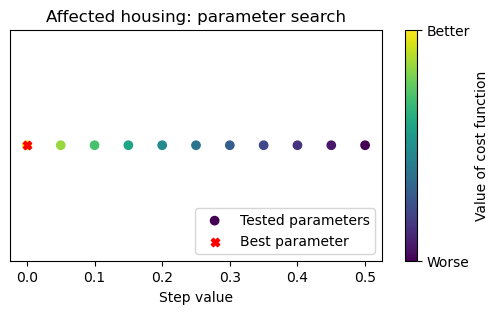

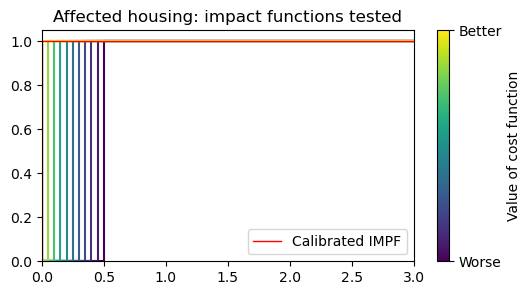

In [13]:
from matplotlib.colors import to_hex

# -------------------------------------------
# Methods to visualize the parameter search
# -------------------------------------------

# Helper function for assigning colours to scatter points
def assign_colour_to_costs(results_df):
    # Map the cost to a color according to viridis, where the best score (lowest) is yellow and the worst score (highest) is purple
    # we can do this by normalising the cost to be between 0 and 1, where 0 corresponds to the best 1 corresponds to the worst score
    # In addition, we take the logarithm of the cost to make the differences between smaller costs more visible
    costs = np.log10(results_df['cost'] + 1e-6)  # Add a small value to avoid taking log of zero
    max_score = costs.max()
    min_score = costs.min()
    norm_scores = 1 - (costs - min_score) / (max_score - min_score)
    results_df['colour'] = [to_hex(plt.cm.viridis(score)) for score in norm_scores]
    results_df = results_df.sort_values('cost', ascending=False)  # Also sort the dataframe by cost so that the best scores are plotted on top
    return results_df

# Plot the parameter search space, with points coloured according to the cost function value (yellow = good, purple = bad)
def plot_step_search_space(results_df, best_step, title):
    results_df = assign_colour_to_costs(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    axis.scatter(results_df['step'], np.zeros_like(results_df['step']), color=results_df['colour'], label='Tested parameters')
    axis.scatter(best_step, 0, color='red', label='Best parameter', marker='X')
    axis.legend(loc="lower right")

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])
    
    axis.set_xlabel("Step value")
    axis.set_yticks([])
    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

# Plot all the impact functions tested in the parameter search, coloured according to the cost function value
def plot_step_search_impfs(results_df, best_step, title):
    results_df = assign_colour_to_costs(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = step_function(params['step'])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = step_function(best_step)
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Calibrated IMPF')
    axis.legend(loc="lower right")

    axis.set_xlim((best_impf.intensity.min(), best_impf.intensity.max()))
    axis.set_ylim((0, 1.05))

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])

    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

plot_step_search_space(results_affected_df, best_affected_parameters['step'], "Affected housing: parameter search")
plot_step_search_impfs(results_affected_df, best_affected_parameters['step'], "Affected housing: impact functions tested")

### Affected housing: the optimized impact function

(Note that we don't call this 'calibrated' – an automated search won't always choose the best function!)

2026-06-04 08:54:03,988 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-04 08:54:04,000 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.
2026-06-04 08:54:04,005 - climada.hazard.base - WARNING - Impact function id=102 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.


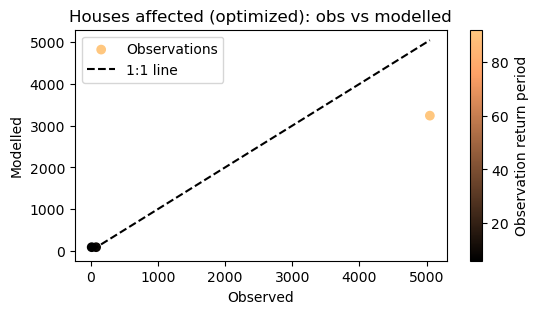

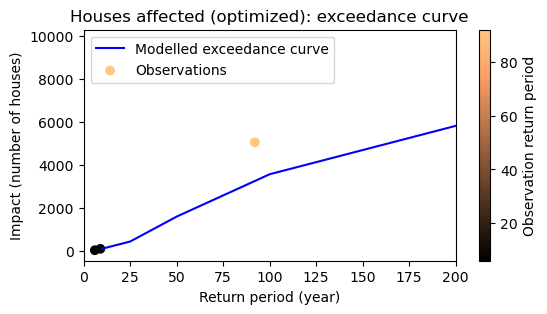

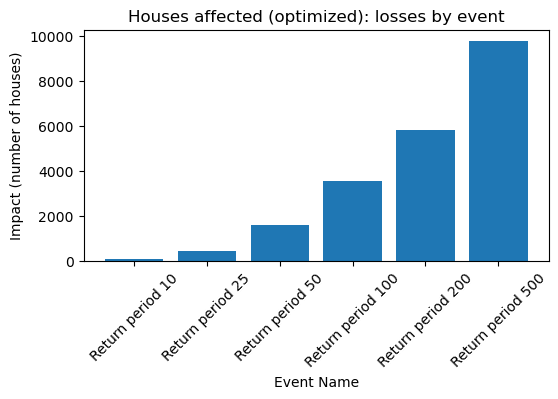

In [14]:
# Recreate the impact calculation with the best parameter values:
impf_best_affected = step_function(best_affected_parameters['step'], fun_id=default_impf_affected.id, name=default_impf_affected.name)

# Update the entity object with the new impact function
entity_affected = replace_impact_function(entity_count, impf_best_affected)

# Rerun the risk calculation and calculate the cost function as before
imp, modelled_stats = risk_calc(entity_affected, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['affected_or_destroyed_present'])

title = f"Houses affected (optimized): obs vs modelled"
plot_observations_vs_modelled(obs["affected_or_destroyed_present"], modelled_stats, title)
title = f"Houses affected (optimized): exceedance curve"
plot_exceedance(imp, obs["affected_or_destroyed_present"], title)
title = f"Houses affected (optimized): losses by event"
plot_event_losses(imp, title=title)

#### Discussion: optimized housing affected

The selected impact function for affected houses is a dramatic one: any hazard at all is considered to have affected a house.

From the plots above we see that this still underestimates the official figures for damaged housing. There could be several reasons for this:
- The damage reports overestimate losses
- The historic event had a larger flood footprint than the return periods we've matched it to (though we chose quite a large return period after seeing how poorly the calibration performed at lower return periods)
- Our exposure data doesn't have enough houses, or they are not located close enough to flooded locations

Each of these would require some more careful validation. For now this is sufficient: in our model we consider any house that experienced flooding to have been affected.

## Destroyed housing calibration: step function

For destroyed housing we also use a step function. The calibration repeats the above calculations, and we expect to find a higher intensity threshold.

### First-guess analysis

Our Entity file has a first-guess impact function for affected housing. This is what we'll be improving on:

First, look at the first-guess results:

2026-06-04 08:54:04,482 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-04 08:54:04,493 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.


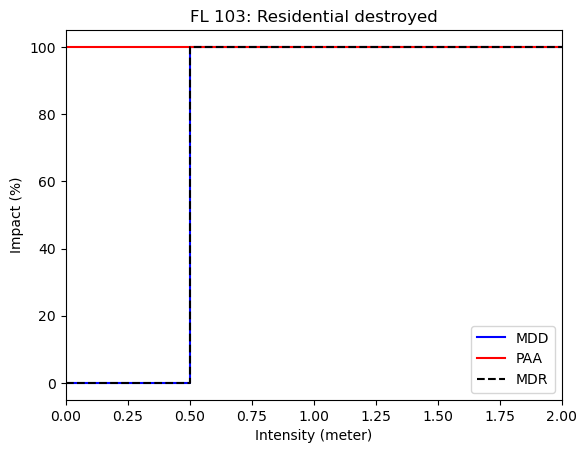

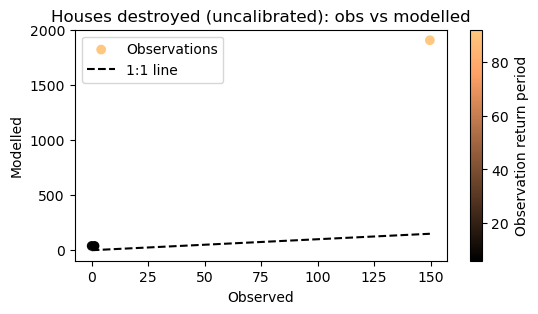

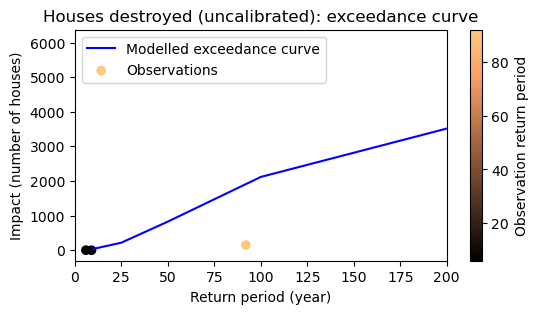

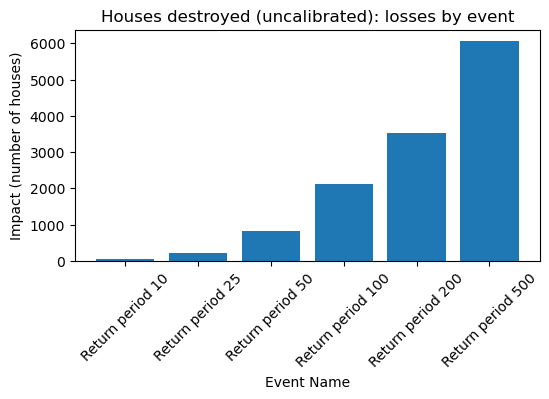

In [15]:
# Modify our Entity to use the default 'destroyed' impact function
default_impf_destroyed = entity_count.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_destroyed)
entity_destroyed = replace_impact_function(entity_count, default_impf_destroyed)

# Calculate risk
imp_destroyed, modelled_destroyed = risk_calc(entity_destroyed, haz, return_periods=obs.index)
cost = cost_function(modelled_destroyed, obs["homes_destroyed_present"])

# Create plots
entity_destroyed.impact_funcs.plot()
title = f"Houses destroyed (uncalibrated): obs vs modelled"
plot_observations_vs_modelled(obs["homes_destroyed_present"], modelled_destroyed, title)
title = f"Houses destroyed (uncalibrated): exceedance curve"
plot_exceedance(imp_destroyed, obs["homes_destroyed_present"], title)
title = f"Houses destroyed (uncalibrated): losses by event"
plot_event_losses(imp_destroyed, title=title)

#### Discussion: first-guess housing destroyed

The intial plots show us a few things that can guide the calibration.:
- We're improving on a first-guess step function where a house is affected if it has 0.5 m of water or more
- This mayjorly _overestimates_ the impacts from the largest event that we have

This means that we want to increase the threshold of the step function to decrease the number of destroyed houses.

### Destroyed housing: parameter search

The next blocks of code define a simple parameter search to choose this value.

In [16]:
parameter_space = {
    "step": np.arange(0.5, 3.05, 0.05)
}

results_destroyed_df = search_for_step_impf(
    entity=entity_destroyed,
    impf_id=impf_id_destroyed,
    step_values=parameter_space["step"],
    obs=obs["homes_destroyed_present"]
)
display(results_destroyed_df)

Running risk calculation for step=0.50 ...
Running risk calculation for step=0.55 ...
Running risk calculation for step=0.60 ...
Running risk calculation for step=0.65 ...
Running risk calculation for step=0.70 ...
Running risk calculation for step=0.75 ...
Running risk calculation for step=0.80 ...
Running risk calculation for step=0.85 ...
Running risk calculation for step=0.90 ...
Running risk calculation for step=0.95 ...
Running risk calculation for step=1.00 ...
Running risk calculation for step=1.05 ...
Running risk calculation for step=1.10 ...
Running risk calculation for step=1.15 ...
Running risk calculation for step=1.20 ...
Running risk calculation for step=1.25 ...
Running risk calculation for step=1.30 ...
Running risk calculation for step=1.35 ...
Running risk calculation for step=1.40 ...
Running risk calculation for step=1.45 ...
Running risk calculation for step=1.50 ...
Running risk calculation for step=1.55 ...
Running risk calculation for step=1.60 ...
Running ris

,step,cost
0,0.50,1017.069979
1,0.55,945.528993
2,0.60,890.250136
3,0.65,832.272268
4,0.70,763.445528
5,0.75,709.509564
6,0.80,650.338785
7,0.85,602.457957
8,0.90,560.452359
9,0.95,514.166336


Best step value: 1.95 with cost: 4.07


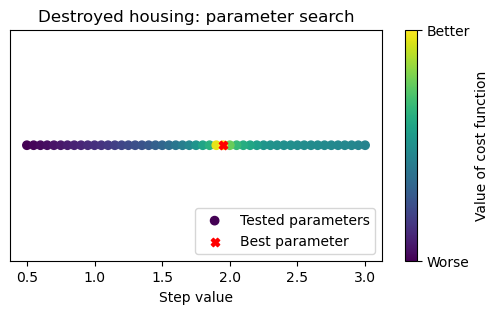

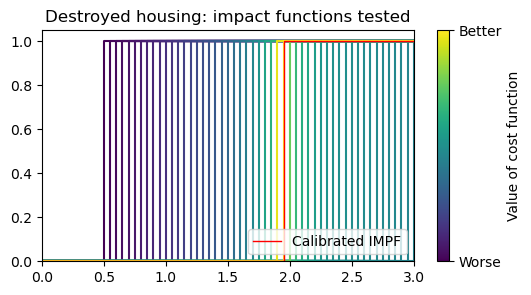

In [17]:
best_destroyed_parameters = get_best_result(results_destroyed_df)
print(f"Best step value: {best_destroyed_parameters['step']:.2f} with cost: {best_destroyed_parameters['cost']:.2f}")

plot_step_search_space(results_destroyed_df, best_destroyed_parameters['step'], title="Destroyed housing: parameter search")
plot_step_search_impfs(results_destroyed_df, best_destroyed_parameters['step'], title="Destroyed housing: impact functions tested")

2026-06-04 08:54:09,859 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-04 08:54:09,871 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.


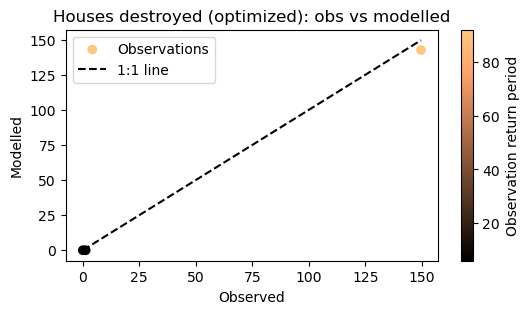

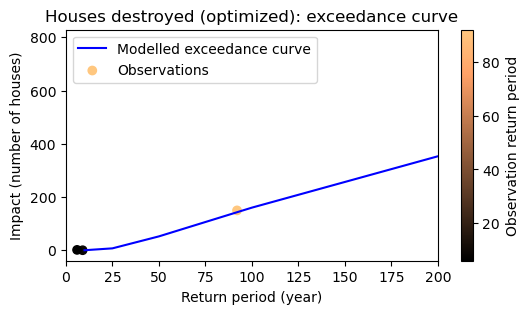

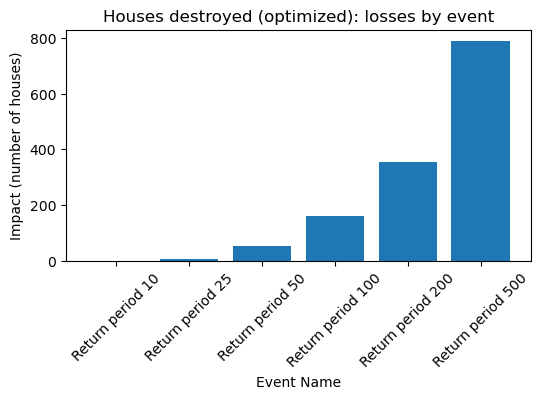

In [18]:
# Recreate the impact calculation with the best parameter values:
impf_best_destroyed = step_function(best_destroyed_parameters['step'], fun_id=default_impf_destroyed.id, name=default_impf_destroyed.name)

# Update the entity object with the new impact function
entity_destroyed = replace_impact_function(entity_count, impf_best_destroyed)

# Rerun the risk calculation and calculate the cost function as before
imp, modelled_stats = risk_calc(entity_destroyed, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['homes_destroyed_present'])

title = f"Houses destroyed (optimized): obs vs modelled"
plot_observations_vs_modelled(obs["homes_destroyed_present"], modelled_stats, title=title)
title = f"Houses destroyed (optimized): exceedance curve"
plot_exceedance(imp, obs["homes_destroyed_present"], title=title)
title = f"Houses destroyed (optimized): losses by event"
plot_event_losses(imp, title=title)

#### Discussion: optimized housing destroyed

The selected impact function - a damage threshold at just below 2m of water depth – feels like a reasonable one for the destruction of a house.

The model is able to reproduce the historical observations with quite some accuracy. It gets realistic low return period impacts (houses are not destroyed every year) and gets the main historic observation right.

Not included here is the uncertainty: the fitted function is sensitive to the return period that we assign to the 2017 flood events – change the value of `RETURN_PERIOD_2017` in these scripts to confirm this.

## Recovery costs: loss curve calibration

Now we look at calibrating a loss curve for economic costs. The goal here is to reproduce the reported government expenditure on recovery and reconstruction of housing.

Note that this is different to the modelling the value of the houses (and contents) lost – the reported expenditure per house is far below the value of a house in our Entity file. 

This calibration is more complex: we want to adjust an existing flood loss curve rather than create one from its functional form. There are a lot of ways to do this: here we will apply scalings along the x- and y-axis to stretch the first-guess function (capping a cap at 100% loss). Other approaches might translate along the x-axis instead of stretching, or might look at ways to change the shape of the function.


### First-guess analysis

Our Entity file has a first-guess impact function for housing losses. This is what we'll be improving on:

First, look at the first-guess results:

2026-06-04 08:54:10,265 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-04 08:54:10,281 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.


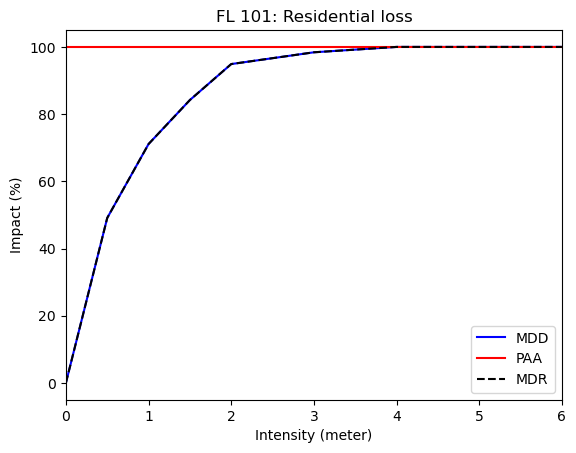

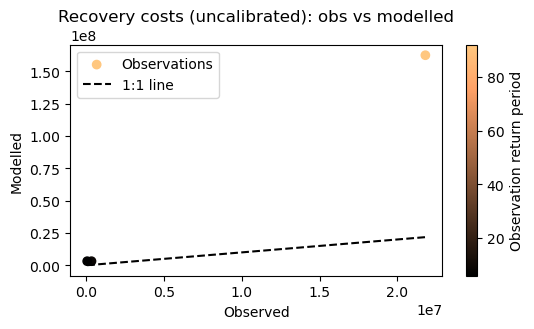

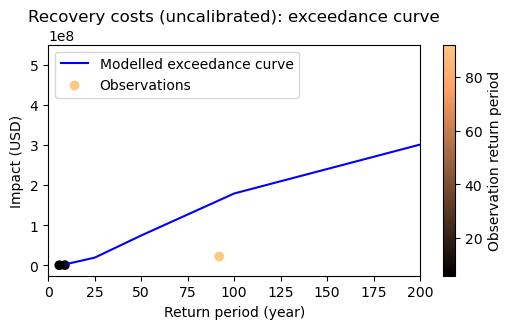

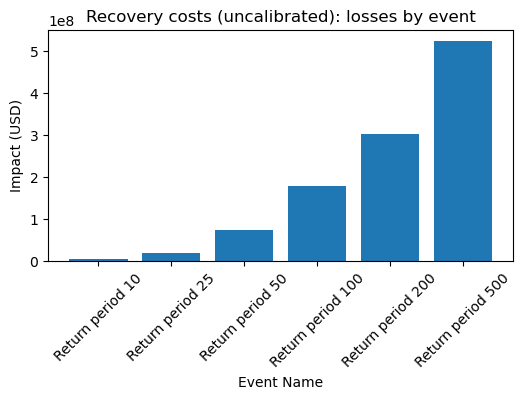

In [19]:
# Calculate uncalibrated losses
imp_losses, modelled_losses = risk_calc(entity_usd, haz, return_periods=obs.index)  # No need to change the impact function since the Entity file is set up to use the loss curve by deafult
cost = cost_function(modelled_losses, obs["recovery_cost_usd"])
default_impf_loss = entity_usd.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_loss)

default_impf_loss.plot()
title = f"Recovery costs (uncalibrated): obs vs modelled"
plot_observations_vs_modelled(obs["recovery_cost_usd"], modelled_losses, title)
title = f"Recovery costs (uncalibrated): exceedance curve"
plot_exceedance(imp_losses, obs["recovery_cost_usd"], title=title)
title = f"Recovery costs (uncalibrated): losses by event"
plot_event_losses(imp_losses, title=title)

#### Discussion: first-guess recovery costs analysis

The intial plots show us a few things that can guide the calibration:
- We're improving on a moderately steep first-guess curve. Losses start quickly (as opposed to, for example, a sigmoid curve), and by 2 m flood depth there is almost 100% loss.
- This agrees with what we found in our 'destroyed' modelling earlier.
- _However_ we know that the 'recovery cost' for a house is far lower than the Entity file's housing value  
- Therefore we see that the first-guess impact function creates losses that are much much higher than the recovery costs.

This means that we want a weaker impact function. We would perhaps imagine a strong scaling on the y-axis so that the maximum possible loss is lower, and small adjustments from x-axis scaling; it makes sense for the function to max out at about 2 m.

### Recovery costs: parameter search

The next blocks of code define the parameter search:

In [20]:
import logging

# This will be a simple grid search, where we loop through all combinations of parameters in a defined parameter space, run the risk calculation for each combination, and calculate the cost function for each combination. 
# We then identify the parameter combination that gives the lowest cost function value.

# First: define the parameter space that we'll be exploring
# We now use two parameters:
parameter_space = {
    "x_scale": np.arange(0.2, 2.6, 0.04),    # Scaling along the x-axis   
    "y_scale": np.arange(0.1, 0.4025, 0.02)    # Scaling along the y-axis
}

# Define a method that scales an impact function
def scale_impf(impf, x_scale, y_scale):
    impf_new = copy.deepcopy(impf)   # Make a copy of the impact function to adjust
    impf_new.intensity = impf_new.intensity * x_scale
    impf_new.mdd = impf_new.mdd * y_scale
    impf_new.mdd = np.clip(impf_new.mdd, 0, 1)   # Ensure that the damage fraction stays between 0 and 1
    return impf_new


def search_for_loss_impf(
        entity: Entity,
        impf_id: int,
        param_space: dict,
        obs: pd.Series
    ):
    # Suppress logging from a couple of climada modules which can be very verbose when running many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for x_scale in param_space["x_scale"]:
        print(f"Running risk calculations for x_scale={x_scale:.3f} with {len(param_space['y_scale'])} y_scale values...")
        for y_scale in param_space["y_scale"]:
            # Create a new impact function based on the original
            impf_loss = entity.impact_funcs.get_func(haz_type='FL', fun_id=impf_id)
            impf_new = scale_impf(impf_loss, x_scale, y_scale)

            # Update the entity object with the new impact function
            entity_new = replace_impact_function(entity, impf_new)

            # Rerun the risk calculation and calculate the cost function as before
            _, modelled_stats = risk_calc(entity_new, haz, return_periods=obs.index)
            cost = cost_function(modelled_stats, obs)

            # Store the results
            results.append({
                "x_scale": x_scale,
                "y_scale": y_scale,
                "cost": cost
            })
    
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)

    return pd.DataFrame(results)

results_loss_df = search_for_loss_impf(
    entity=entity_usd,
    impf_id=impf_id_loss,
    param_space=parameter_space,
    obs=obs["recovery_cost_usd"]
)
display(results_loss_df.sort_values('cost').head(10))


Running risk calculations for x_scale=0.200 with 16 y_scale values...
Running risk calculations for x_scale=0.240 with 16 y_scale values...
Running risk calculations for x_scale=0.280 with 16 y_scale values...
Running risk calculations for x_scale=0.320 with 16 y_scale values...
Running risk calculations for x_scale=0.360 with 16 y_scale values...
Running risk calculations for x_scale=0.400 with 16 y_scale values...
Running risk calculations for x_scale=0.440 with 16 y_scale values...
Running risk calculations for x_scale=0.480 with 16 y_scale values...
Running risk calculations for x_scale=0.520 with 16 y_scale values...
Running risk calculations for x_scale=0.560 with 16 y_scale values...
Running risk calculations for x_scale=0.600 with 16 y_scale values...
Running risk calculations for x_scale=0.640 with 16 y_scale values...
Running risk calculations for x_scale=0.680 with 16 y_scale values...
Running risk calculations for x_scale=0.720 with 16 y_scale values...
Running risk calcula

,x_scale,y_scale,cost
887,2.40,0.24,179409.618996
790,2.16,0.22,182574.422563
677,1.88,0.20,191636.062239
467,1.36,0.16,199379.880253
580,1.64,0.18,205493.383187
354,1.08,0.14,208023.921005
903,2.44,0.24,212653.769371
241,0.80,0.12,219206.859090
774,2.12,0.22,229586.589428
693,1.92,0.20,230010.414795


Best parameter combination: x_scale: 2.40, y_scale: 0.24 with cost: 179409.62


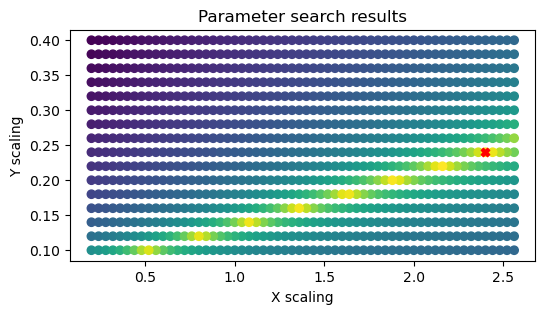

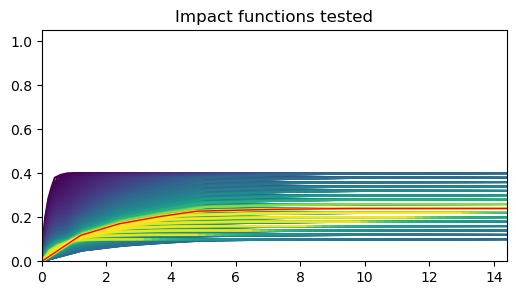

In [21]:
# ------------------------------------
# Visualize the parameter search results, now in two dimensions
# ------------------------------------

def plot_loss_search_space(results_df, best_params):
    # Map the cost to a color according to viridis, where the best score (lowest) is yellow and the worst score (highest) is purple
    # we can do this by normalising the cost to be between 0 and 1, where 0 corresponds to the best 1 corresponds to the worst score
    results_df = assign_colour_to_costs(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    axis.scatter(results_df['x_scale'], results_df['y_scale'], color=results_df['colour'])
    axis.scatter(best_params['x_scale'], best_params['y_scale'], color='red', label='Best parameter combination', marker='X')
    axis.set_xlabel("X scaling")
    axis.set_ylabel("Y scaling")
    axis.set_title("Parameter search results")

def plot_loss_search_impfs(results_df, best_params, impf_orig):
    results_df = assign_colour_to_costs(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = scale_impf(impf_orig, params['x_scale'], params['y_scale'])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = scale_impf(impf_orig, best_params['x_scale'], best_params['y_scale'])
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Calibrated IMPF')

    axis.set_xlim((best_impf.intensity.min(), best_impf.intensity.max()))
    axis.set_ylim((0, 1.05))
    axis.set_title("Impact functions tested")

    plt.show()
    plt.close(axis.figure)

best_loss_parameters = get_best_result(results_loss_df)
print(f"Best parameter combination: x_scale: {best_loss_parameters['x_scale']:.2f}, y_scale: {best_loss_parameters['y_scale']:.2f} with cost: {best_loss_parameters['cost']:.2f}")

impf_orig = entity_usd.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_loss)
plot_loss_search_space(results_loss_df, best_loss_parameters)
plot_loss_search_impfs(results_loss_df, best_loss_parameters, impf_orig)

2026-06-04 08:55:45,491 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-04 08:55:45,506 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.


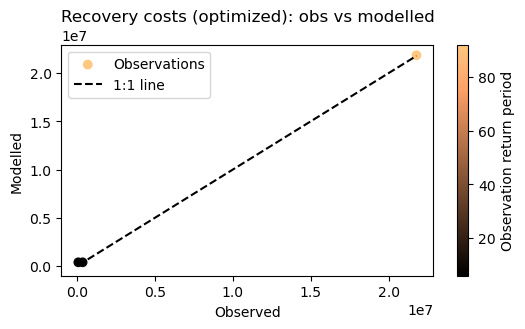

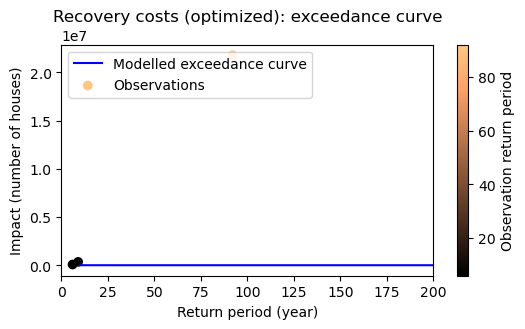

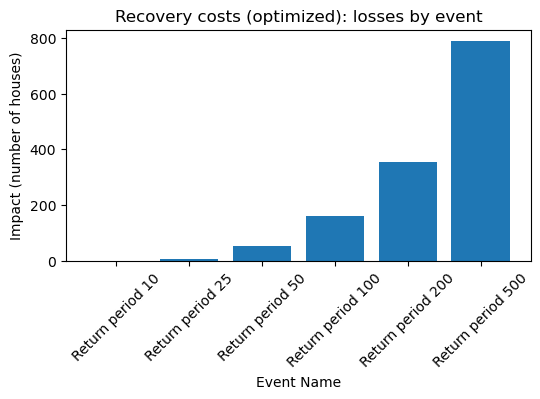

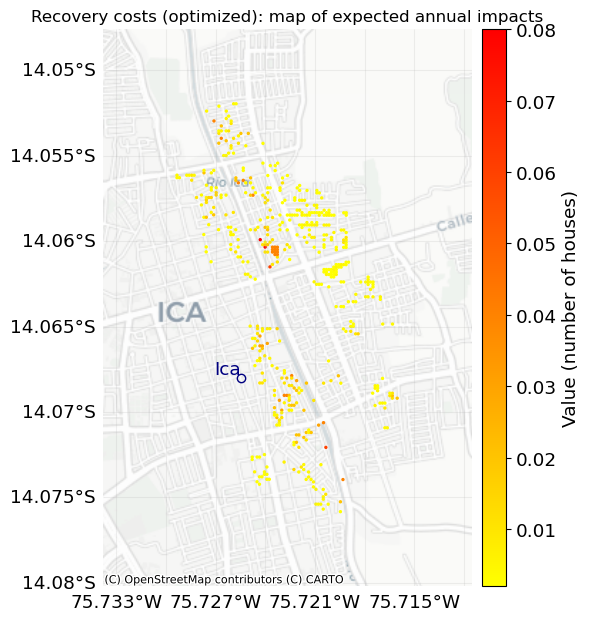

In [22]:
# Recreate the impact calculation with the best parameter values:
impf_best_loss = scale_impf(impf_orig, best_loss_parameters['x_scale'], best_loss_parameters['y_scale'])

# Update the entity object with the new impact function
entity_loss = replace_impact_function(entity_usd, impf_best_loss)

# Rerun the risk calculation and calculate the cost function as before
imp_optimized, modelled_stats = risk_calc(entity_loss, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs['recovery_cost_usd'])

title = f"Recovery costs (optimized): obs vs modelled"
plot_observations_vs_modelled(obs["recovery_cost_usd"], modelled_stats, title=title)
title = f"Recovery costs (optimized): exceedance curve"
plot_exceedance(imp, obs["recovery_cost_usd"], title=title)
title = f"Recovery costs (optimized): losses by event"
plot_event_losses(imp, title=title)
title = f"Recovery costs (optimized): map of expected annual impacts"
plot_map(imp, title=title)

#### Discussion: optimized recover costs analysis

The selected impact function is a curve that scales the first-guess impact function to 20% of its original value and which reaches its highest impacts at about 4 m of flood depth.

The model is able to reproduce the historical observations with quite some accuracy. It gets realistic low return period impacts (houses are not destroyed every year) and gets the main historic observations right.

Is the 20% value correct? It's not bad: we might expect something even less, given that the maximum payout for an individual house is less than 20% of its value.

Is the lower curve correct, capping out around 4 m? Maybe not: we expect maximum payouts at about 2 m. It's also likely that the impacts from shallower water depths are being underestimated, since we know these are significant from the calibration of the 'affected' step function.

How would we improve this function? Looking at the above plot of the cost function in the two-dimensional parameter space, we can see that there is a linear band of similarly-good choices in yellow stretching from lower left to upper right, including a region with lower x_scale and y_scale values, i.e. relatively steeper curves that cap out sooner. The cost function is similar across the entire band.

I would therefore suggest taking one of these functions: a slightly less efficient match in the cost function is worth a better agreement with the theory.

For example, how do results change with `x_scale = 0.8` `y_scale = 0.12`?

2026-06-04 08:55:47,790 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-04 08:55:47,804 - climada.engine.impact_calc - INFO - Calculating impact for 29925 assets (>0) and 6 events.
Optimized cost function: 179410
Alternative cost function: 219207


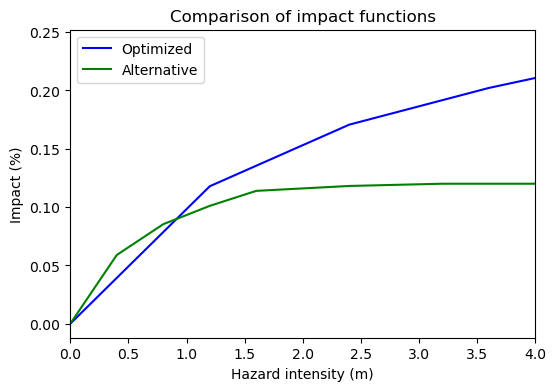

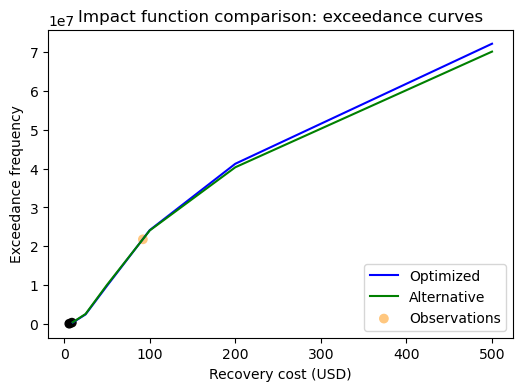

In [23]:
# Create a new impact function based on the original
alt_x_scale = 0.8
alt_y_scale = 0.12
impf_loss_default = entity_usd.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_loss)
impf_alt_loss = scale_impf(impf_loss_default, alt_x_scale, alt_y_scale)

# Update the entity object with the new impact function
entity_alt = replace_impact_function(entity_usd, impf_alt_loss)

# Rerun the risk calculation and calculate the cost function as before
imp_alt, modelled_stats = risk_calc(entity_alt, haz, return_periods=obs.index)
cost = cost_function(modelled_stats, obs["recovery_cost_usd"])

# Store the results
results_alt = {
    "x_scale": alt_x_scale,
    "y_scale": alt_y_scale,
    "cost": cost
}

print(f"Optimized cost function: {best_loss_parameters['cost']:.0f}")
print(f"Alternative cost function: {results_alt['cost']:.0f}")

# Plot the two impact functions
fig, axis = plt.subplots(figsize=(6, 4))
axis.plot(impf_best_loss.intensity, impf_best_loss.mdd, color='blue', label='Optimized')
axis.plot(impf_alt_loss.intensity, impf_alt_loss.mdd, color='green', label='Alternative')
axis.set_xlabel("Hazard intensity (m)")
axis.set_ylabel("Impact (%)")
axis.set_xlim((0, 4))
axis.legend(loc="upper left")
axis.set_title("Comparison of impact functions")

# Compare the two Exceedance curves
fig, axis = plt.subplots(figsize=(6, 4))
# Plot the optimized curve
exceedance_curve_opt = imp_optimized.calc_freq_curve()
exceedance_curve_alt = imp_alt.calc_freq_curve()
exceedance_curve_opt.plot(axis=axis, color="blue", label="Optimized")
exceedance_curve_alt.plot(axis=axis, color="green", label="Alternative")
axis.scatter(obs.index, obs["recovery_cost_usd"], c=obs.index, cmap="copper", label="Observations")
# axis.set_xlim(0, 500)  # Don't zoom in on lower return periods
axis.set_title("Impact function comparison: exceedance curves")
axis.set_xlabel("Recovery cost (USD)")
axis.set_ylabel("Exceedance frequency")
axis.legend(loc="lower right")
plt.show()
plt.close(axis.figure)

We see that, while these are quite different functions, they create remarkably similar exceedance curves. We can conclude that the results are not very sensitive to this choice, and so it's reasonable to pick the one that makes more 'intuitive' sense here.

## Write calibrated Entity file

In [ ]:
import shutil

entity_final = copy.deepcopy(entity_usd)

# Swap in the new impact functions for loss, affected, and destroyed
new_impfset = ImpactFuncSet([impf_alt_loss, impf_best_affected, impf_best_destroyed])
old_impf_ids = [impf.id for impf in entity_final.impact_funcs.get_func(haz_type='FL')]
new_impf_ids = [impf.id for impf in new_impfset.get_func(haz_type='FL')]
assert np.array_equal(old_impf_ids, new_impf_ids), "The new impact function IDs do not match the old ones"
entity_final.impact_funcs = new_impfset

# Drop unnecessary columns that were added to the Exposures GeoDataFrame
new_gdf = entity_final.exposures.gdf.copy()
columns_to_drop = [col for col in new_gdf.columns if col.startswith("centr_")]
new_gdf = new_gdf.drop(columns=columns_to_drop)
entity_final.exposures.set_gdf(new_gdf)

# Copy over original file and update with calibrated impact functions
shutil.copy(entity_filepath, calibrated_entity_filepath)

# Open the impact_functions sheet in the Excel file and overwrite with the new impact functions
impf_export_list = []
for impf in [impf_alt_loss, impf_best_affected, impf_best_destroyed]:
    impf_df = pd.DataFrame({
        "impact_fun_id": impf.id,
        "intensity_m": impf.intensity,
        "mdd": impf.mdd,
        "paa": impf.paa,
        "peril_id": "FL",
        "name": impf.name,
        "intensity_unit": "meter"
    })
    impf_export_list.append(impf_df)

impf_export_df = pd.concat(impf_export_list, ignore_index=True)

print(f"Final impact functions. Copy into Excel file to overwrite the original impact functions:")
display(impf_export_df)
